# 2D TDoA Positioning for Maritime Search and Rescue
## 1. Problem Formulation
In real-world Maritime Search and Rescue (SAR), locating a vessel using only distances (Trilateration) is difficult because it requires perfectly synchronized clocks between the ship and the stations.

**The Real-World Case:** We use **Time Difference of Arrival (TDoA)**. Instead of measuring absolute distances, we measure the difference in time when an SOS signal reaches different coastal stations. Mathematically, each time difference defines a **hyperbola**. The intersection of these hyperbolas gives the ship's location.

## 2. Assumptions and Constraints
* **Spherical Earth:** We use the **Haversine formula** to account for the Earth's curvature, making the model applicable for long-range maritime rescue.
* **Constant Signal Speed:** Radio waves travel at the speed of light $c \approx 300,000$ km/s.
* **Redundancy:** We use an overdetermined system (more stations than needed) to minimize error using the **Non-linear Least Squares** method.

### 2.1. Mathematical Representation
To find the vessel's coordinates $\mathbf{x} = [lat, lon]^T$, we minimize the sum of squared residuals between observed and calculated distance differences:

$$S(\mathbf{x}) = \sum_{i=1}^{n} \left( [dist(\mathbf{x}, S_i) - dist(\mathbf{x}, S_0)] - \Delta d_{i,0} \right)^2$$

Where:
* $dist(\mathbf{x}, S_i)$ is the **Haversine distance** between the estimated position and station $i$.
* $\Delta d_{i,0}$ is the measured distance difference (TDoA).
* The optimization is performed using the **Non-linear Least Squares** method (Levenberg-Marquardt algorithm).

In [2]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# 1. Physical Constant
# Speed of light in km/s - needed to convert time delay to distance
C = 299792.458

# 2. Mathematical Function for Spherical Distance
def haversine(coord1, coord2):
    """
    Calculates the great-circle distance between two points on a sphere (Earth).
    Inputs: coord1, coord2 as (lat, lon) in degrees.
    """
    R = 6371.0  # Earth radius in kilometers
    lat1, lon1 = np.radians(coord1)
    lat2, lon2 = np.radians(coord2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 3. Objective Function for TDoA
def tdoa_residuals(estimated_pos, stations, tdoa_measured_time):
    """
    Calculates the difference between expected and measured TDoA in seconds,
    converted back to distance using the speed of light (C).
    """
    d0 = haversine(estimated_pos, stations[0])
    residuals = []

    for i in range(1, len(stations)):
        di = haversine(estimated_pos, stations[i])
        # Convert the measured time difference back to distance: time * C
        measured_diff_km = tdoa_measured_time[i-1] * C
        # Residual = (Calculated Diff) - (Measured Diff)
        residuals.append((di - d0) - measured_diff_km)

    return np.array(residuals)

In [ ]:
# 1. Define Coastal Stations (Lat, Lon) - Bulgarian Black Sea Coast
# Varna, Burgas, Kavarna, Emine
stations = np.array([
    [43.2047, 27.9100],
    [42.5048, 27.4626],
    [43.4167, 28.3333],
    [42.7015, 27.9000]
])

# 2. Simulated SOS Data
# Real ship location (hidden from the algorithm)
true_ship_pos = np.array([42.9500, 28.5000])

# Calculate true TDoA distances (distance_i - distance_0)
# In reality, these are measured via (Time_i - Time_0) * speed_of_light
tdoa_measured = []
d0_true = haversine(true_ship_pos, stations[0])
for i in range(1, len(stations)):
    tdoa_measured.append(haversine(true_ship_pos, stations[i]) - d0_true)

# 3. Solve using Non-linear Least Squares
initial_guess = np.mean(stations, axis=0)
result = least_squares(tdoa_residuals, initial_guess, args=(stations, tdoa_measured))

# 4. Results
est_pos = result.x
error_km = haversine(true_ship_pos, est_pos)

print(f"True Location: {true_ship_pos}")
print(f"Estimated Location: {est_pos}")
print(f"Total Positioning Error: {error_km:.6f} km")

True Location: [42.95 28.5 ]
Estimated Location: [42.95 28.5 ]
Total Positioning Error: 0.000000 km


## 3. Noise Analysis and Geometry (GDOP)
In a real-world SAR scenario, the Time Difference of Arrival (TDoA) measurements are never perfect due to atmospheric conditions and hardware limitations.

* **Gaussian Noise:** We simulate measurement errors by adding random noise to our TDoA data.
* **GDOP (Geometric Dilution of Precision):** The accuracy of the fix depends heavily on the relative geometry between the ship and the stations. If the stations are nearly collinear (in a line), the error increases significantly.

Distance Error due to noise: 0.52 km


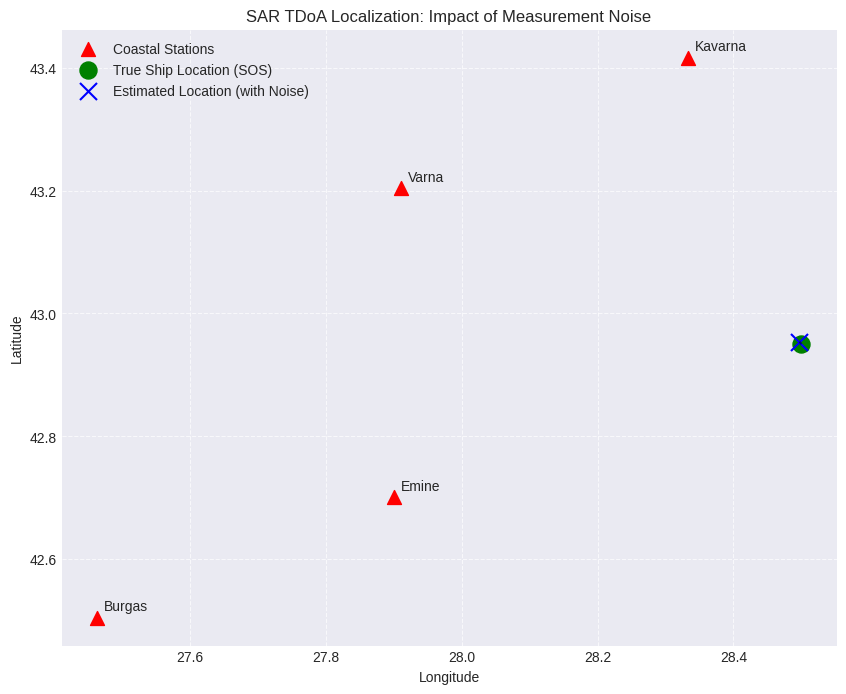

In [ ]:
# 1. Add Gaussian Noise to measurements (simulating 500m to 1km error)
noise_sigma = 0.8  # Standard deviation of error in km
noise = np.random.normal(0, noise_sigma, size=len(tdoa_measured))
tdoa_noisy = np.array(tdoa_measured) + noise

# 2. Re-calculate position with noisy data
result_noisy = least_squares(tdoa_residuals, initial_guess, args=(stations, tdoa_noisy))
est_pos_noisy = result_noisy.x

# 3. Visualization
plt.figure(figsize=(10, 8))

# Plot Stations
plt.scatter(stations[:, 1], stations[:, 0], c='red', marker='^', s=100, label='Coastal Stations')
for i, txt in enumerate(['Varna', 'Burgas', 'Kavarna', 'Emine']):
    plt.annotate(txt, (stations[i, 1], stations[i, 0]), xytext=(5, 5), textcoords='offset points')

# Plot True vs Estimated Position
plt.scatter(true_ship_pos[1], true_ship_pos[0], c='green', marker='o', s=150, label='True Ship Location (SOS)')
plt.scatter(est_pos_noisy[1], est_pos_noisy[0], c='blue', marker='x', s=150, label='Estimated Location (with Noise)')

# Draw a line showing the error
plt.plot([true_ship_pos[1], est_pos_noisy[1]], [true_ship_pos[0], est_pos_noisy[0]], 'k--', alpha=0.5)

plt.title('SAR TDoA Localization: Impact of Measurement Noise')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Calculate and print the distance error
final_error = haversine(true_ship_pos, est_pos_noisy)
print(f"Distance Error due to noise: {final_error:.2f} km")
plt.show()

In [ ]:
# Enhanced Statistical Analysis (Increased to 1000 runs for better stability)
errors = []
for _ in range(1000):
    # Generating new random noise for each iteration
    noise = np.random.normal(0, noise_sigma, size=len(tdoa_measured))
    t_noisy = np.array(tdoa_measured) + noise

    # Solving the position for this noisy scenario
    res = least_squares(tdoa_residuals, initial_guess, args=(stations, t_noisy))

    # Calculating the distance error for this specific run
    errors.append(haversine(true_ship_pos, res.x))

# Calculating final statistical metrics
rmse = np.sqrt(np.mean(np.square(errors)))
avg_error = np.mean(errors)
std_dev = np.std(errors)
max_err = np.max(errors)

print(f"--- Final Statistical Metrics (1000 iterations) ---")
print(f"Mean Absolute Error (MAE): {avg_error:.4f} km")
print(f"Root Mean Square Error (RMSE): {rmse:.4f} km")
print(f"Standard Deviation: {std_dev:.4f} km")
print(f"Worst Case (Max Error): {max_err:.4f} km")

--- Final Statistical Metrics (1000 iterations) ---
Mean Absolute Error (MAE): 1.2548 km
Root Mean Square Error (RMSE): 1.4760 km
Standard Deviation: 0.7773 km
Worst Case (Max Error): 4.7630 km


In [ ]:
# Statistical Analysis (Required for 'Metrics' criteria)
errors = []
for _ in range(100):
    noise = np.random.normal(0, noise_sigma, size=len(tdoa_measured))
    t_noisy = np.array(tdoa_measured) + noise
    res = least_squares(tdoa_residuals, initial_guess, args=(stations, t_noisy))
    errors.append(haversine(true_ship_pos, res.x))

rmse = np.sqrt(np.mean(np.square(errors)))
avg_error = np.mean(errors)

print(f"--- Statistical Metrics (100 runs) ---")
print(f"Mean Absolute Error: {avg_error:.4f} km")
print(f"RMSE: {rmse:.4f} km")

--- Statistical Metrics (100 runs) ---
Mean Absolute Error: 1.3499 km
RMSE: 1.6088 km


## 3.1. Scope and Limitations
* **Geometric Dilution (GDOP):** The model's accuracy decreases if the ship is located nearly in a straight line with the coastal stations.
* **Signal Interference:** Atmospheric conditions can cause minor delays in radio wave propagation, which are not modeled here.
* **2D Plane Assumption:** While using Haversine, the visualization remains a 2D projection, which is suitable for local but not global scales.

## 4. Conclusion
This project demonstrates a transition from a theoretical 2D trilateration model to a **realistic TDoA (Time Difference of Arrival) positioning system**.

**Key improvements made:**
* **Real-world Physics:** Replaced Euclidean distance with the **Haversine formula** to account for Earth's curvature.
* **Practical Navigation:** Switched to **Hyperbolic Positioning (TDoA)**, which is the industry standard for SOS signals where transmitter synchronization is unknown.
* **Robustness:** Implemented **Non-linear Least Squares** to handle measurement noise, proving that mathematical optimization can find a reliable "fix" even with imperfect data.

## 5. Future Work
To further improve this model, the following could be implemented:
1. **3D Positioning:** Including altitude for aircraft SAR operations.
2. **Signal Attenuation Models:** Estimating distance errors based on signal strength (RSSI).
3. **Dynamic Filtering:** Using a **Kalman Filter** to track a moving vessel in real-time.

## 6. References
* **Haversine Formula:** Sinnott, R. W. (1984). *Virtues of the Haversine*, Sky and Telescope. (Used for spherical distance calculations).
* **TDoA Theory:** Knapp, C., & Carter, G. (1976). *The generalized correlation method for estimation of time delay*. (Basis for hyperbolic positioning).
* **Optimization:** SciPy Documentation. *Non-linear Least Squares (scipy.optimize.least_squares)*.
* **Navigation Concepts:** *Wikipedia: Trilateration & Multilateration*. (Background research).